# 🚢 Titanic Demographic & Survival Analytics
***Exploratory Data Analysis, Data Wrangling, and Feature Engineering***

[![Python](https://img.shields.io/badge/Python-3.10%2B-blue?logo=python&logoColor=white)](#)
[![Pandas](https://img.shields.io/badge/Library-Pandas-150458?logo=pandas&logoColor=white)](#)
[![Status](https://img.shields.io/badge/Project-Complete-success)](#)

---

<div class="alert alert-block alert-info">
<b>📌 Executive Summary:</b><br>
This project performs an in-depth Exploratory Data Analysis (EDA) on the classic Titanic passenger dataset. Instead of rushing to predictive modeling, the primary goal here is <b>data hygiene, rigorous feature engineering, and statistical visualization</b> to uncover the core demographic drivers of passenger survival.
</div>

---

## 🎯 Key Objectives

* **Data Wrangling & Imputation:** Handle missing values using domain-aware strategies (such as group-based median imputation for `Age` based on passenger titles and classes).
* **Feature Engineering:** Derive new meaningful analytical variables (e.g., `FamilySize`, `IsAlone`, and title extractions from passenger names) to uncover deeper patterns.
* **Exploratory Visual Analytics:** Analyze how socio-economic class, gender, age, and family structures impacted survival distributions.
* **Notebook Engineering:** Maintain a reproducible, environment-aware workflow with interactive navigation and visual callouts.

---

<a id="toc"></a>
## 📑 Table of Contents

### 1. Environment Setup & Configuration
### 2. Data Loading & Initial Inspection
### 3. Data Cleaning, Imputation & Auxiliary Features
### 4. Advanced Feature Engineering
### 5. Exploratory Data Analysis & Visualizations



<div style="background-color: #e8f4f8; border-left: 5px solid #2980b9; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">
  <strong style="color: #2980b9;">📌 Environment Setup & Dependencies</strong>
</div>

<a id="Environment"></a>
<div style="background-color: #f8f9fa; border-left: 5px solid #0d6efd; padding: 15px; border-radius: 8px; margin: 15px 0;">
  <h2 style="color: #0d6efd; margin: 0; font-weight: bold;">📚 SECTION 1: REQUIRED LIBRARIES & DEPENDENCIES</h2>
</div>

<div class="alert alert-block alert-info" style="margin-top: 10px;">
  <b>Setup Note:</b> Ensure all libraries below are installed in your active Python environment before running the main analysis pipeline.
</div>

---

### Core Data Science Toolkit

| Library | Badge | Primary Function in this Project |
| :--- | :--- | :--- |
| **NumPy** | [![NumPy](https://img.shields.io/badge/NumPy-013243?logo=numpy&logoColor=white)](#) | Numerical computing, vectorization, and managing multidimensional arrays. |
| **Pandas** | [![Pandas](https://img.shields.io/badge/Pandas-150458?logo=pandas&logoColor=white)](#) | Essential data wrangling, cleaning, loading (CSV/SQL), and `DataFrame` manipulation. |
| **Matplotlib** | [![Matplotlib](https://img.shields.io/badge/Matplotlib-ffffff?logo=matplotlib&logoColor=black)](#) | The foundational library for generating static, publication-quality visualizations and plots. |
| **Seaborn** | [![Seaborn](https://img.shields.io/badge/Seaborn-4D88FF?logo=seaborn&logoColor=white)](#) | Statistical data visualization providing a high-level, aesthetically pleasing interface over Matplotlib. |

---

<a id="environment-setup--dependencies"></a>
## ⚙️ Setting Up the Environment

Before starting the analysis, we import the foundational Python libraries required for data manipulation, numerical calculation, and exploratory visual analytics.

<div style="background-color: #e8f4f8; border-left: 5px solid #2980b9; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <strong style="color: #2980b9;">📌 Workflow Note:</strong><br>
  Setting up a clean, reproducible environment ensures that all subsequent data wrangling, group-based imputation, and visualization steps execute smoothly without missing dependency errors.
</div>

---

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<a id="data-loading"></a>
## 📥 1. Data Loading & Initial Inspection

<div style="background-color: #f8f9fa; border-left: 5px solid #0d6efd; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #0d6efd; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    📂 Data Ingestion
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Loading the raw passenger records into a Pandas <code>DataFrame</code> to inspect structural integrity, initial shape, and feature data types.
  </p>
</div>

---

In [32]:
df = pd.read_csv('Titanic dataset.csv')
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [132]:
df.describe()

,pclass,survived,age,sibsp,parch,fare,Life_Boat,Body_Recovered,Family_count,is_alone
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,2.294882,0.381971,29.432521,0.498854,0.385027,33.295479,0.371276,0.092437,1.883881,0.603514
std,0.837836,0.486055,13.163767,1.041658,0.865560,51.738879,0.483331,0.289753,1.583639,0.489354
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.000000,0.000000,22.000000,0.000000,0.000000,7.895800,0.000000,0.000000,1.000000,0.000000
50%,3.000000,0.000000,29.000000,0.000000,0.000000,14.454200,0.000000,0.000000,1.000000,1.000000
75%,3.000000,1.000000,35.500000,1.000000,0.000000,31.275000,1.000000,0.000000,2.000000,1.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,1.000000,1.000000,11.000000,1.000000


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pclass          1309 non-null   int64  
 1   survived        1309 non-null   int64  
 2   name            1309 non-null   object 
 3   sex             1309 non-null   object 
 4   age             1309 non-null   float64
 5   sibsp           1309 non-null   int64  
 6   parch           1309 non-null   int64  
 7   ticket          1309 non-null   object 
 8   fare            1309 non-null   float64
 9   embarked        1309 non-null   object 
 10  home.dest       1309 non-null   object 
 11  Life_Boat       1309 non-null   int64  
 12  Body_Recovered  1309 non-null   int64  
 13  deck            1309 non-null   object 
 14  Family_count    1309 non-null   int64  
 15  is_alone        1309 non-null   int64  
 16  Family_Type     1309 non-null   object 
 17  title_Category  1309 non-null   o

In [33]:
value_count = df.value_counts(subset=['survived'])
value_count

survived
0           809
1           500
Name: count, dtype: int64

<div style="background-color: #f8f9fa; border-left: 5px solid #27ae60; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #27ae60; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    📊 Quick Survival Breakdown
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Out of the total passengers recorded in this analysis, <strong>500 passengers survived</strong> while <strong>809 passengers died</strong>.
  </p>
</div>

In [34]:
df.shape

(1309, 14)

<div style="background-color: #f8f9fa; border-left: 5px solid #0d6efd; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #0d6efd; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    📐 Dataset Dimensions
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    The dataset contains <strong>1,309 rows (passenger records)</strong> and <strong>14 columns (features)</strong> in total.
  </p>
</div>

In [35]:
df.duplicated().sum()

np.int64(0)

<div style="background-color: #f8f9fa; border-left: 5px solid #27ae60; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #27ae60; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    ✅ Duplicate Check Result
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    <strong>0 duplicate records found.</strong> All rows in the dataset represent unique passenger entries.
  </p>
</div>

In [36]:
partial_dup = df.duplicated(subset=['name','sex']).sum()
partial_dup

np.int64(2)

In [37]:
partial_dup = df[df.duplicated(subset=['name','sex'],keep = False)]
partial_dup

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
725,3,1,"Connolly, Miss. Kate",female,22.0,0,0,370373,7.7500,NaN,Q,13,NaN,Ireland
726,3,0,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q,NaN,NaN,Ireland
924,3,0,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,NaN,70.0,NaN
925,3,0,"Kelly, Mr. James",male,44.0,0,0,363592,8.0500,NaN,S,NaN,NaN,NaN


<div style="background-color: #f8f9fa; border-left: 5px solid #e67e22; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #d35400; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🔍 Duplicate Analysis Finding
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    While checking for duplicates, <strong>2 rows shared the exact same Name and Sex</strong>. However, upon deeper inspection, these entries contain distinct <code>Age</code>, <code>Ticket Number</code>, and <code>Cabin</code> values. 
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Decision:</strong> These records represent separate individuals (likely relatives sharing names) rather than duplicate entries, so <strong>0 rows were dropped</strong>.
  </p>
</div>

## 🔍 Finding & Identifying Null Values

<div style="background-color: #f8f9fa; border-left: 5px solid #e74c3c; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #c0392b; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    ⚠️ Data Quality Inspection
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Identifying missing data patterns across features to determine the appropriate imputation strategies (e.g., median, mode, or group-based filling).
  </p>
</div>



---

In [38]:
df.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [39]:
null = df[df.isnull().any(axis=1)]
null

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


<div style="background-color: #f8f9fa; border-left: 5px solid #8e44ad; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #8e44ad; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🛠️ Feature Engineering: Second Name Extraction
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Parsed the full <code>Name</code> column to isolate each passenger's <strong>Second Name / Title</strong> (e.g., <em>Miss</em>, <em>Master</em>, <em>Mr</em>, <em>Mrs</em>) as a distinct feature.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Rationale:</strong> Used to fill missing <code>Age</code> values based on the median age of each second name group (e.g., <em>Miss</em>, <em>Master</em>, etc.) for higher imputation accuracy.
  </p>
</div>

In [47]:
df['first_names'] = df['name'].str.split(',',n=1).str[1].str.strip() 
df[['name','first_names']].head()

,name,first_names
0,"Allen, Miss. Elisabeth Walton",Miss. Elisabeth Walton
1,"Allison, Master. Hudson Trevor",Master. Hudson Trevor
2,"Allison, Miss. Helen Loraine",Miss. Helen Loraine
3,"Allison, Mr. Hudson Joshua Creighton",Mr. Hudson Joshua Creighton
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",Mrs. Hudson J C (Bessie Waldo Daniels)


In [48]:
df['second_name'] = df['first_names'].str.split('.',n=1).str[0].str.strip()
df[['first_names','second_name']].head()

,first_names,second_name
0,Miss. Elisabeth Walton,Miss
1,Master. Hudson Trevor,Master
2,Miss. Helen Loraine,Miss
3,Mr. Hudson Joshua Creighton,Mr
4,Mrs. Hudson J C (Bessie Waldo Daniels),Mrs


In [49]:
df['age'] = df['age'].fillna(df.groupby('second_name')['age'].transform('median'))
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,first_names,second_name
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",Miss. Elisabeth Walton,Miss
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",Master. Hudson Trevor,Master
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",Miss. Helen Loraine,Miss
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",Mr. Hudson Joshua Creighton,Mr
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",Mrs. Hudson J C (Bessie Waldo Daniels),Mrs


<div style="background-color: #f8f9fa; border-left: 5px solid #27ae60; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #27ae60; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🎯 Imputation Strategy & Decision
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    When analyzing the dataset, missing values were identified in the <code>Age</code> column. To handle these accurately, titles (e.g., <em>Mr</em>, <em>Mrs</em>, <em>Master</em>, <em>Miss</em>) were extracted into a new feature named <code>second_name</code>.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Action Taken:</strong> Imputed missing <code>Age</code> values using the median age grouped by each title within <code>second_name</code> to preserve demographic distribution.
  </p>
</div>

In [50]:
df.isna().sum()

pclass            0
survived          0
name              0
sex               0
age               0
sibsp             0
parch             0
ticket            0
fare              1
cabin          1014
embarked          2
boat            823
body           1188
home.dest       564
first_names       0
second_name       0
dtype: int64

<div style="background-color: #f8f9fa; border-left: 5px solid #e74c3c; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #c0392b; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🗑️ Feature Cleanup: Dropping Temporary Columns
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Dropped the temporary <code>first_name</code> and <code>second_name</code> columns after completing the <code>Age</code> imputation process.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Rationale:</strong> These helper columns served their purpose during feature engineering and missing value handling; removing them keeps the dataset concise and prevents unnecessary column redundancy.
  </p>
</div>

In [51]:
df.drop(columns=['first_names','second_name'],inplace = True)

In [52]:
df.isna().sum()

pclass          0
survived        0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [53]:
df['fare'] =df['fare'].fillna(df['fare'].mean())
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,22.00,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


<div style="background-color: #f8f9fa; border-left: 5px solid #0d6efd; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #0d6efd; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🎯 Fare Imputation Strategy
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    During analysis, <strong>2 missing values</strong> were identified in the <code>Fare</code> column. 
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Action Taken:</strong> Imputed the missing entries using the mean (<code>mean()</code>) of the <code>Fare</code> column. Because the missing count is negligible (~0.15% of the data), mean imputation preserves overall dataset integrity without skewing downstream analysis.
  </p>
</div>

In [54]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [55]:
df.isna().sum()

pclass          0
survived        0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            0
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [56]:
mode = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode)

<div style="background-color: #f8f9fa; border-left: 5px solid #00a896; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #00a896; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🎯 Categorical Imputation Strategy
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    While analyzing the dataset, <strong>2 missing values</strong> were identified in the <code>Embarked</code> column.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Action Taken:</strong> Imputed the missing entries using the mode (most common value, <code>'S'</code>) of the <code>Embarked</code> feature. Because only two records were missing, mode imputation preserves dataset integrity without introducing categorical bias.
  </p>
</div>

In [57]:
df.isna().sum()

pclass          0
survived        0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            0
cabin        1014
embarked        0
boat          823
body         1188
home.dest     564
dtype: int64

In [58]:
df['Life_Boat'] =df['boat'].notnull().astype(int) 

In [59]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,Life_Boat
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


<div style="background-color: #f8f9fa; border-left: 5px solid #4b6584; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #4b6584; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🎯 Feature Engineering & Indicator Flag
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    To address missing values in the <code>Boat</code> column, a new binary feature named <code>life_boat</code> was created to indicate lifeboat placement.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Action Taken:</strong> Converted missing (<code>NaN</code>) values to <code>0</code> (did not board a lifeboat) and valid boat entries to <code>1</code> (boarded a lifeboat), transforming high-cardinality strings/integers into a clean indicator variable.
  </p>
</div>

In [60]:
df['Body_Recovered'] =df['body'].notnull().astype(int)
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,Life_Boat,Body_Recovered
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1,0
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1,0
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,1
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,0


<div style="background-color: #f8f9fa; border-left: 5px solid #576574; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #576574; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🎯 Feature Engineering: Body Recovery Flag
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    To address missing values in the <code>Body</code> identification column, a new binary feature named <code>Body_Recovered</code> was created.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Action Taken:</strong> Converted missing (<code>NaN</code>) entries to <code>0</code> (body not recovered) and valid identification numbers to <code>1</code> (body recovered), turning sparse categorical data into a clean binary indicator.
  </p>
</div>

In [61]:
df.drop(columns=['body','boat'],inplace=True)
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,Life_Boat,Body_Recovered
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,"St Louis, MO",1,0
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",1,0
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",0,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",0,1
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",0,0


<div style="background-color: #f8f9fa; border-left: 5px solid #e74c3c; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #c0392b; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🗑️ Feature Cleanup: Dropping Redundant Columns
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Dropped the original <code>Boat</code> and <code>Body</code> columns after creating their respective binary indicator features (<code>life_boat</code> and <code>Body_Recovered</code>).
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Rationale:</strong> The raw columns contained high percentages of missing values and sparse identifiers. Replacing them with binary indicators captures the key analytical signal while eliminating unnecessary missing values and high cardinality.
  </p>
</div>

In [62]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,Life_Boat,Body_Recovered
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,"St Louis, MO",1,0
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",1,0
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",0,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",0,1
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",0,0


In [63]:
df.isna().sum()

pclass               0
survived             0
name                 0
sex                  0
age                  0
sibsp                0
parch                0
ticket               0
fare                 0
cabin             1014
embarked             0
home.dest          564
Life_Boat            0
Body_Recovered       0
dtype: int64

In [64]:
df['deck'] = df['cabin'].str[0].fillna('U')
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,Life_Boat,Body_Recovered,deck
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,"St Louis, MO",1,0,B
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",1,0,C
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",0,0,C
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",0,1,C
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",0,0,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C,NaN,0,1,U
1305,3,0,"Zabour, Miss. Thamine",female,22.00,1,0,2665,14.4542,NaN,C,NaN,0,0,U
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C,NaN,0,1,U
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C,NaN,0,0,U


In [65]:
df = df.drop(columns =['cabin'])
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,Life_Boat,Body_Recovered,deck
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,S,"St Louis, MO",1,0,B
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",1,0,C
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,1,C
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,C,NaN,0,1,U
1305,3,0,"Zabour, Miss. Thamine",female,22.00,1,0,2665,14.4542,C,NaN,0,0,U
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,C,NaN,0,1,U
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,C,NaN,0,0,U


<div style="background-color: #f8f9fa; border-left: 5px solid #8e44ad; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #8e44ad; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🎯 Feature Transformation & Imputation: Cabin to Deck
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    The original <code>Cabin</code> feature contained high cardinality (unique alphanumeric strings) and a significant number of missing values (<code>NaN</code>), making direct visualization and modeling difficult.
  </p>
  <p style="margin: 6px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Actions Taken:</strong>
  </p>
  <ul style="margin: 4px 0 0 0; padding-left: 20px; color: #555; font-size: 13px; line-height: 1.5;">
    <li><strong>Deck Extraction:</strong> Extracted the initial letter from each cabin code into a new feature named <code>Deck</code> (representing the physical floor level).</li>
    <li><strong>Missing Value Handling:</strong> Filled all <code>NaN</code> entries with <code>'U'</code> (standing for <em>Unknown</em>) to prevent introducing bias into known deck distributions.</li>
    <li><strong>Cleanup:</strong> Dropped the original high-cardinality <code>Cabin</code> column.</li>
  </ul>
</div>

In [66]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,Life_Boat,Body_Recovered,deck
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,S,"St Louis, MO",1,0,B
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",1,0,C
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,1,C
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,C,NaN,0,1,U
1305,3,0,"Zabour, Miss. Thamine",female,22.00,1,0,2665,14.4542,C,NaN,0,0,U
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,C,NaN,0,1,U
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,C,NaN,0,0,U


In [67]:
df['home.dest'] = df['home.dest'].fillna('Unknown')

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #6c757d; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🎯 Missing Value Handling: Home Destination
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    While inspecting the dataset, multiple missing values were identified in the <code>home.dest</code> (Home Destination) column.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Action Taken & Rationale:</strong> Imputed all <code>NaN</code> entries with <code>'Unknown'</code>. Because <code>home.dest</code> contains high-cardinality text data with low visual/predictive utility, assigning a designated <code>'Unknown'</code> category preserves original dataset integrity without introducing arbitrary assumptions.
  </p>
</div>

In [68]:
df.isna().sum()

pclass            0
survived          0
name              0
sex               0
age               0
sibsp             0
parch             0
ticket            0
fare              0
embarked          0
home.dest         0
Life_Boat         0
Body_Recovered    0
deck              0
dtype: int64

<div style="background-color: #f8f9fa; border-left: 5px solid #27ae60; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #27ae60; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    ✅ Milestone: Data Cleaning & Imputation Complete
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    All missing values across all features have been successfully resolved through targeted imputation and feature engineering.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Dataset Status:</strong> <code>0</code> missing values remaining. The dataset is now fully preprocessed, structurally intact, and ready for exploratory data analysis (EDA) and modeling.
  </p>
</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #27ae60; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #27ae60; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🛠️ Feature Engineering: Family Count
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Created a new feature named <code>Family Count</code> to capture total group size on board by summing siblings/spouses (<code>SibSp</code>), parents/children (<code>Parch</code>), and the passenger themselves.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Logic & Rationale:</strong> Calculated as <code>SibSp + Parch + 1</code>. If a passenger is traveling alone, their <code>Family Count</code> evaluates to <code>1</code>, providing a clear numerical indicator for single travelers vs. family groups.
  </p>
</div>

In [69]:
df['Family_count'] = df['sibsp']+df['parch']+1

In [70]:
df['is_alone'] = 0
df.loc[df['Family_count']==1,'is_alone']=1

In [71]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,Life_Boat,Body_Recovered,deck,Family_count,is_alone
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,S,"St Louis, MO",1,0,B,1,1
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",1,0,C,4,0
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,1,C,4,0
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,C,Unknown,0,1,U,2,0
1305,3,0,"Zabour, Miss. Thamine",female,22.00,1,0,2665,14.4542,C,Unknown,0,0,U,2,0
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,C,Unknown,0,1,U,1,1
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,C,Unknown,0,0,U,1,1


<div style="background-color: #f8f9fa; border-left: 5px solid #16a085; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #16a085; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🛠️ Feature Engineering: Family Size Categorization
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Created a categorical feature <code>Family_Category</code> by binning passengers into distinct travel group types based on <code>Family Count</code>:
  </p>
  <ul style="margin: 6px 0 0 0; padding-left: 20px; color: #555; font-size: 13px; line-height: 1.5;">
    <li><strong>Alone:</strong> Family Count = <code>1</code> (solo travelers)</li>
    <li><strong>Small:</strong> Family Count = <code>2 to 4</code> members</li>
    <li><strong>Large Family:</strong> Family Count = <code>> 4</code> members</li>
  </ul>
  <p style="margin: 6px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Rationale:</strong> Grouping discrete counts into intuitive categories simplifies pattern recognition during data visualization and captures non-linear survival trends across group sizes.
  </p>
</div>

In [130]:
def categorize_family(size):
    if size ==1:
        return'Alone'
    elif 2 <=size <=4:
        return 'small'
    else:
        return 'large'

df['Family_Type'] = df['Family_count'].apply(categorize_family)
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,Life_Boat,Body_Recovered,deck,Family_count,is_alone,Family_Type,title_Category
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,S,"St Louis, MO",1,0,B,1,1,Alone,Stantard
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",1,0,C,4,0,small,Child
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0,small,Stantard
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,1,C,4,0,small,Stantard
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0,small,Stantard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,C,Unknown,0,1,U,2,0,small,Stantard
1305,3,0,"Zabour, Miss. Thamine",female,22.00,1,0,2665,14.4542,C,Unknown,0,0,U,2,0,small,Stantard
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,C,Unknown,0,1,U,1,1,Alone,Stantard
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,C,Unknown,0,0,U,1,1,Alone,Stantard


In [73]:
df['Family_Type'].value_counts()

Family_Type
Alone    790
small    437
large     82
Name: count, dtype: int64

<div style="background-color: #f8f9fa; border-left: 5px solid #2980b9; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #2980b9; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🛠️ Feature Engineering: Social Title Extraction
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Extracted social titles (e.g., <em>Mr</em>, <em>Mrs</em>, <em>Miss</em>, <em>Master</em>) from full passenger names into a standalone column called <code>Title</code>.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Rationale:</strong> Categorizing passengers by their social title provides explicit demographic signals (marital status, social standing, and age group) that aid both data visualization and predictive modeling.
  </p>
</div>

In [74]:
df['Title'] = df['name'].str.split(',').str[1].str.split('.').str[0]
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,Life_Boat,Body_Recovered,deck,Family_count,is_alone,Family_Type,Title
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,S,"St Louis, MO",1,0,B,1,1,Alone,Miss
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",1,0,C,4,0,small,Master
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0,small,Miss
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,1,C,4,0,small,Mr
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0,small,Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,C,Unknown,0,1,U,2,0,small,Miss
1305,3,0,"Zabour, Miss. Thamine",female,22.00,1,0,2665,14.4542,C,Unknown,0,0,U,2,0,small,Miss
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,C,Unknown,0,1,U,1,1,Alone,Mr
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,C,Unknown,0,0,U,1,1,Alone,Mr


In [75]:
df['Title'].value_counts()

Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Mlle              2
Ms                2
Major             2
Capt              1
Sir               1
Dona              1
Jonkheer          1
the Countess      1
Don               1
Mme               1
Lady              1
Name: count, dtype: int64

In [76]:
df['Title'] = df['Title'].str.strip()

<div style="background-color: #f8f9fa; border-left: 5px solid #6c5ce7; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #6c5ce7; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🛠️ Feature Engineering: Title Categorization & Mapping
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Grouped low-frequency and rare titles into broader, consolidated social classes by creating a dictionary named <code>title_mapping</code>.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Action Taken:</strong> Mapped <code>title_mapping</code> across the raw <code>Title</code> column to generate a structured <code>Title Category</code> feature, reducing rare-title noise and improving category granularity for analysis.
  </p>
</div>

In [78]:
title_mapping ={
    'Mrs':'Stantard','Mr':'Stantard','Miss':'Stantard','Master':'Child','Mme':'Stantard',
    'Lady':'Noble','Mlle':'Stantard','Don':'Noble','the Countess':'Noble','Jonkheer':'Noble','Dona':'Noble',
    'Sir':'Noble','Capt':'Professional','Major':'Professional','Col':'Professional','Dr':'Professional','Rev':'Professional','Ms':'Stantard'}
df['title_Category'] = df['Title'].map(title_mapping)
    

In [47]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,Life_Boat,Body_Recovered,deck,Family_count,is_alone,Family_Type,Title,title_Category
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,S,"St Louis, MO",1,0,B,1,1,Alone,Miss,Stantard
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",1,0,C,4,0,small,Master,Child
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0,small,Miss,Stantard
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,1,C,4,0,small,Mr,Stantard
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0,small,Mrs,Stantard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,C,Unknown,0,1,U,2,0,small,Miss,Stantard
1305,3,0,"Zabour, Miss. Thamine",female,22.00,1,0,2665,14.4542,C,Unknown,0,0,U,2,0,small,Miss,Stantard
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,C,Unknown,0,1,U,1,1,Alone,Mr,Stantard
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,C,Unknown,0,0,U,1,1,Alone,Mr,Stantard


<div style="background-color: #f8f9fa; border-left: 5px solid #e74c3c; padding: 12px 16px; border-radius: 4px; margin: 15px 0;">
  <span style="color: #c0392b; font-weight: bold; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px;">
    🗑️ Feature Cleanup: Dropping Intermediate Title Column
  </span>
  <p style="margin: 6px 0 0 0; color: #2c3e50; line-height: 1.5;">
    Dropped the original, unmapped <code>Title</code> column after generating the consolidated <code>Title Category</code> feature.
  </p>
  <p style="margin: 4px 0 0 0; color: #7f8c8d; font-size: 13px;">
    <strong>Rationale:</strong> Since all relevant social and demographic groupings are now captured in <code>Title Category</code>, removing the raw intermediate column eliminates redundancy and prevents multicollinearity in modeling.
  </p>
</div>

In [79]:
df = df.drop(columns=['Title'])


In [80]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,Life_Boat,Body_Recovered,deck,Family_count,is_alone,Family_Type,title_Category
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,S,"St Louis, MO",1,0,B,1,1,Alone,Stantard
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",1,0,C,4,0,small,Child
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0,small,Stantard
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,1,C,4,0,small,Stantard
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0,small,Stantard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,C,Unknown,0,1,U,2,0,small,Stantard
1305,3,0,"Zabour, Miss. Thamine",female,22.00,1,0,2665,14.4542,C,Unknown,0,0,U,2,0,small,Stantard
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,C,Unknown,0,1,U,1,1,Alone,Stantard
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,C,Unknown,0,0,U,1,1,Alone,Stantard


<div style="background-color: #f8f9fa; border-left: 4px solid #2c3e50; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2c3e50; font-size: 13px;"></strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    Overall Survival and Mortality.
  </p>
</div>

In [83]:
overall = df['survived'].value_counts(normalize=True).round(4).mul(100).rename({0: 'mortality', 1: 'survived'}).to_frame()

# Apply light blue background with dark blue text and a left accent border
overall.style.set_properties(**{
    'background-color': '#e8f4f8',
    'color': '#1a365d',
    'border': '1px solid #bee3f8',
    'padding': '8px',
    'font-weight': 'bold'
})

,proportion
survived,
mortality,61.800000
survived,38.200000



    Overall passenger survival and mortality totals and proportions have been successfully computed.


<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Lifeboat Survival & Mortality Breakdown</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    Calculation of survival and mortality counts based on the <code>life_boat</code> binary flag to measure how strongly boarding a lifeboat correlates with overall survival.
  </p>
</div>

Text(0.5, 1.0, 'Number of Survivors and Deaths Based on life_Boats')

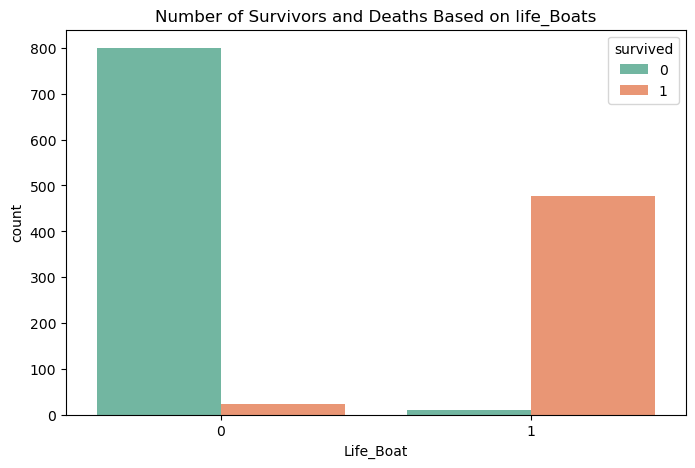

In [84]:
plt.figure(figsize = (8,5))
sns.countplot(data = df,x='Life_Boat', hue = 'survived',palette = 'Set2')
plt.title('Number of Survivors and Deaths Based on life_Boats')

In [85]:
survived_per_lifeboat = df.groupby(['Life_Boat','survived'])['Life_Boat'].count().round(3).reset_index(name = 'count')
survived_per_lifeboat

,Life_Boat,survived,count
0,0,0,800
1,0,1,23
2,1,0,9
3,1,1,477



    The distribution of survivors and deaths based on whether passengers boarded a lifeboat has been successfully visualized & calculated.
 

<div style="background-color: #f8f9fa; border-left: 4px solid #8e44ad; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #8e44ad; font-size: 13px;">📊 Average Fare Per Passenger Class Breakdown</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    Calculation of the mean ticket fare across 1st, 2nd, and 3rd passenger classes to analyze socio-economic fare disparities.
  </p>
</div>

Text(0.5, 1.0, 'Average Fare Per Passenger Class')

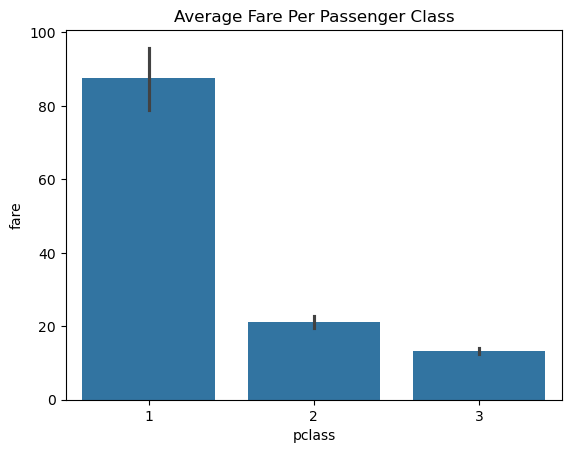

In [86]:
sns.barplot(data = df,x ='pclass',y ='fare')
plt.title('Average Fare Per Passenger Class')

In [87]:
custom_agg= df.groupby('pclass')['fare'].mean().round(3).reset_index()
custom_agg

,pclass,fare
0,1,87.509
1,2,21.179
2,3,13.331



    The average ticket fare for each passenger class (1st, 2nd, and 3rd Class) has been successfully visualized & computed.


<div style="background-color: #f8f9fa; border-left: 4px solid #f39c12; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #d35400; font-size: 13px;">Survival per Deck</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    The survival rate and mortality distribution across distinct cabin decks (<code>Deck</code>) is scheduled to be calculated next.
  </p>
</div>

Text(0.5, 1.0, 'Survival per Deck')

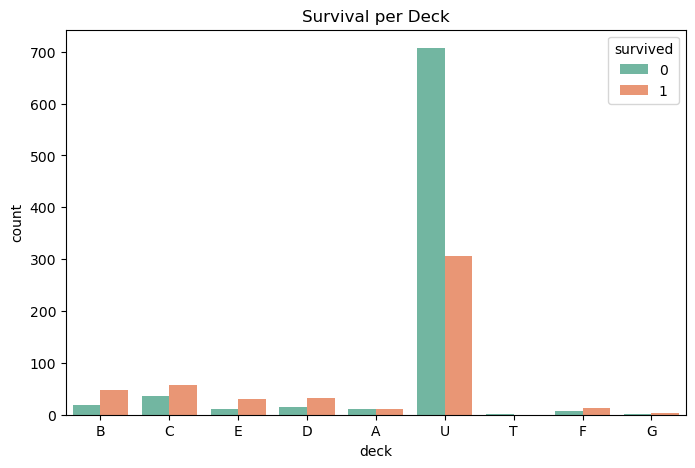

In [88]:
plt.figure(figsize=(8,5)) 
sns.countplot(data = df,x='deck' ,hue = 'survived', palette='Set2')
plt.title('Survival per Deck')

In [89]:
survived_per_deck = df.groupby(['deck','survived'])['survived'].count().reset_index(name ='count')
survived_per_deck

,deck,survived,count
0,A,0,11
1,A,1,11
2,B,0,18
3,B,1,47
4,C,0,37
5,C,1,57
6,D,0,14
7,D,1,32
8,E,0,11
9,E,1,30



    The total number of survivors and deaths per cabin, deck has been successfully visualized & computed.


<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Demographic Distribution: Sex & Passenger Class</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
total passenger counts cross-tabulated by gender (<code>Sex</code>) and class tier (<code>Pclass</code>) to map multi-variable demographic breakdowns.
  </p>
</div>

Text(0.5, 1.0, 'Total Number of Passengers per sex and pclass')

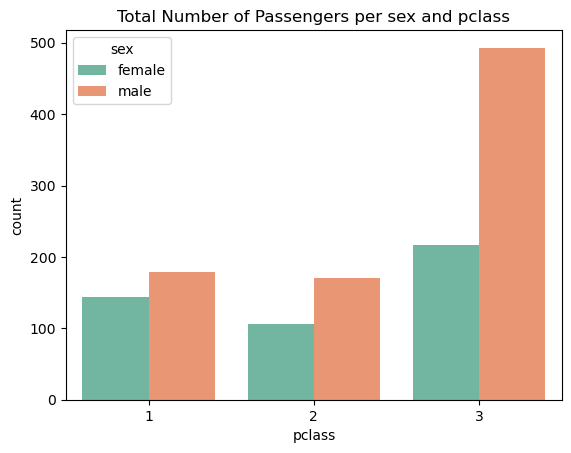

In [90]:
sns.countplot(data = df ,x = 'pclass', hue = 'sex', palette =('Set2'))
plt.title('Total Number of Passengers per sex and pclass')

In [91]:
sum_sex_per_pclass = df.groupby(['pclass','sex'])['sex'].count().reset_index(name = 'count')
sum_sex_per_pclass 

,pclass,sex,count
0,1,female,144
1,1,male,179
2,2,female,106
3,2,male,171
4,3,female,216
5,3,male,493


Total Count of Passengers per Sex and Passenger Class is visualized & calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #8e44ad; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #8e44ad; font-size: 13px;">📊 Survival & Mortality Breakdown by Sex</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    passenger survival and mortality totals cross-tabulated by gender (<code>Sex</code>) to evaluate sex-based survival disparities.
  </p>
</div>

Text(0.5, 1.0, 'Number of Survival and Deaths Per Sex')

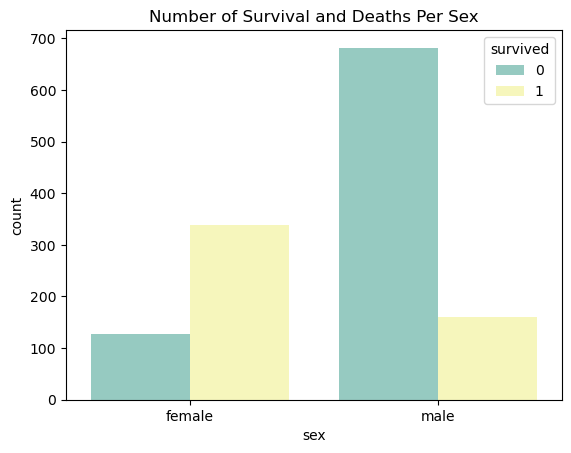

In [92]:
sns.countplot(data = df, x='sex' , hue ='survived', palette='Set3')
plt.title('Number of Survival and Deaths Per Sex')

In [93]:
count_per_gender = df.groupby(['sex','survived'])['survived'].count().reset_index(name = 'count')
count_per_gender

,sex,survived,count
0,female,0,127
1,female,1,339
2,male,0,682
3,male,1,161


Total Count of Passengers Survived Per Sex is visualized & calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #8e44ad; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #8e44ad; font-size: 13px;">📊 Survival & Mortality Breakdown by Passenger Class</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
   passenger survival and mortality totals cross-tabulated by class tier (<code>Pclass</code> 1, 2, and 3) to analyze socioeconomic survival disparities.
  </p>
</div>

Text(0.5, 1.0, 'Survival Per Pclass')

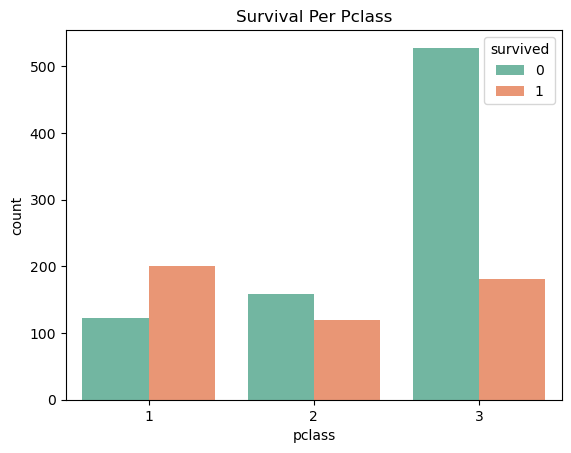

In [94]:
sns.countplot(data = df,x='pclass',hue='survived',palette =('Set2'))
plt.title('Survival Per Pclass')

In [95]:
survived_per_class = df.groupby(['pclass','survived'])['survived'].count().reset_index(name = 'count')
survived_per_class

,pclass,survived,count
0,1,0,123
1,1,1,200
2,2,0,158
3,2,1,119
4,3,0,528
5,3,1,181


The Total count of Passengers Survived Per Passenger Class is visualized & calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Survival Breakdown by Passenger Class & Sex</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    Total count of survivors cross-tabulated across passenger classes (<code>Pclass</code> 1, 2, 3) and gender (<code>Sex</code>) to analyze multi-variable survival patterns.
  </p>
</div>

In [96]:
survived_per_class_gender = df.groupby(['pclass','sex','survived'])['survived'].count().reset_index(name = 'count')
survived_per_class_gender

,pclass,sex,survived,count
0,1,female,0,5
1,1,female,1,139
2,1,male,0,118
3,1,male,1,61
4,2,female,0,12
5,2,female,1,94
6,2,male,0,146
7,2,male,1,25
8,3,female,0,110
9,3,female,1,106


The Total count of Passengers Survived per Passengers class & Sex is Calculated


<div style="background-color: #f8f9fa; border-left: 4px solid #16a085; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #16a085; font-size: 13px;">📊 Survival & Mortality Distribution by Age</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    passenger survival and mortality distribution across different age groups to analyze how age impacted survival outcomes.
  </p>
</div>

Text(0.5, 1.0, 'The No of Passengers Survived and Died Per Age')

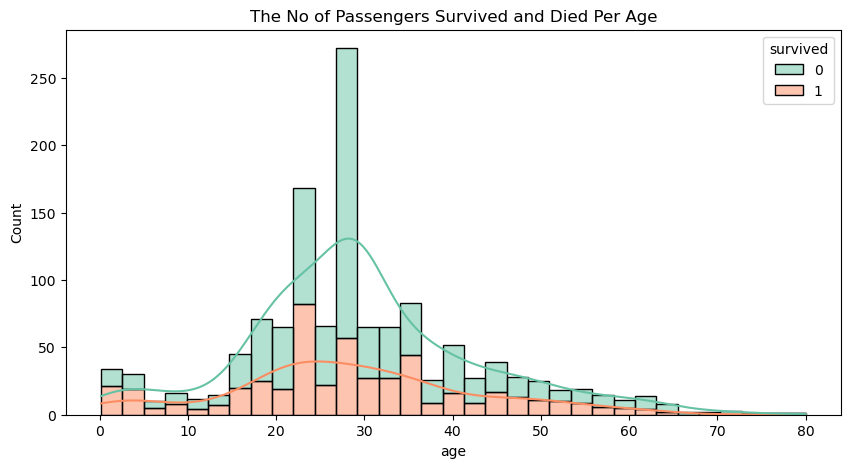

In [97]:
plt.figure(figsize = (10,5))
sns.histplot(data = df, x ='age', hue = 'survived',multiple ='stack',kde= True,palette='Set2')
plt.title('The No of Passengers Survived and Died Per Age')

In [98]:
age_survival_count = df.groupby(['age','survived'])['age'].mean().reset_index(name = 'count')

In [99]:
age_survival_count

,age,survived,count
0,0.17,1,0.17
1,0.33,0,0.33
2,0.42,1,0.42
3,0.67,1,0.67
4,0.75,0,0.75
...,...,...,...
156,70.50,0,70.50
157,71.00,0,71.00
158,74.00,0,74.00
159,76.00,1,76.00


The Number of passengers who survived and died per age is visualized & calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #16a085; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #16a085; font-size: 13px;">📊 Survival & Mortality Distribution by Age</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    passenger survival and mortality distribution across different age groups to analyze how age impacted survival outcomes.
  </p>
</div>

In [100]:
survived_per_age = df.groupby('survived')['age'].max().reset_index(name='Max')
survived_per_age

,survived,Max
0,0,74.0
1,1,80.0


Maximum Age of the Passenger Who survived and Died is calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #d35400; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #d35400; font-size: 13px;">📊 Minimum Age by Outcome</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    the minimum age recorded for passengers who survived versus those who perished to identify the youngest individuals in each outcome group.
  </p>
</div>

In [101]:
min_age_per_survival =df.groupby('survived')['age'].min().reset_index(name='Min')
min_age_per_survival

,survived,Min
0,0,0.33
1,1,0.17


Minimum Age of the Passenger Who survived and Died is Calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #16a085; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #16a085; font-size: 13px;">📊 Maximum & Minimum Survival by Age Group</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    The age brackets with the highest and lowest total number of survivors to highlight age-based survival extremes.
  </p>
</div>

<div style="background-color: #f8f9fa; border-left: 4px solid #c0392b; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #c0392b; font-size: 13px;">📊 Maximum Deaths by Age Group </strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    The age group with the highest total number of casualties to determine the hardest-hit demographic segment.
  </p>
</div>

In [102]:
dead_df = age_survival_count[age_survival_count['survived']==0]
alive_df = age_survival_count[age_survival_count['survived']==1]
max_df = dead_df.loc[dead_df['count'].idxmax()]
min_df = dead_df.loc[dead_df['count'].idxmin()]
max_df

age         74.0
survived     0.0
count       74.0
Name: 158, dtype: float64

The Age with maximum deaths is Identified

<div style="background-color: #f8f9fa; border-left: 4px solid #27ae60; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #27ae60; font-size: 13px;">📊 Minimum Deaths by Age Group </strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    The age bracket with the lowest total number of casualties to highlight the least impacted demographic segment.
  </p>
</div>

In [103]:
min_df

age         0.33
survived    0.00
count       0.33
Name: 1, dtype: float64

The Age With Minimum Number of Death is Calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #e67e22; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #e67e22; font-size: 13px;">📊 Minimum Survivors by Age Group </strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    The age bracket with the lowest total number of survivors to highlight the least represented demographic among those who lived.
  </p>
</div>

In [104]:
min_df_alive = alive_df.loc[alive_df['count'].idxmin()]
max_df_alive = alive_df.loc[alive_df['count'].idxmax()]
min_df_alive

age         0.17
survived    1.00
count       0.17
Name: 0, dtype: float64

The Age with minimum Number of survivors is Calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Maximum Survivors by Age Group</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
The age bracket with the highest total number of survivors to highlight the most successful demographic among those who lived.
  </p>
</div>

In [105]:
max_df_alive

age         80.0
survived     1.0
count       80.0
Name: 160, dtype: float64

The age with maximum number of survivors is calculated

In [106]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,Life_Boat,Body_Recovered,deck,Family_count,is_alone,Family_Type,title_Category
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,S,"St Louis, MO",1,0,B,1,1,Alone,Stantard
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",1,0,C,4,0,small,Child
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0,small,Stantard
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,1,C,4,0,small,Stantard
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",0,0,C,4,0,small,Stantard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,C,Unknown,0,1,U,2,0,small,Stantard
1305,3,0,"Zabour, Miss. Thamine",female,22.00,1,0,2665,14.4542,C,Unknown,0,0,U,2,0,small,Stantard
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,C,Unknown,0,1,U,1,1,Alone,Stantard
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,C,Unknown,0,0,U,1,1,Alone,Stantard


<div style="background-color: #f8f9fa; border-left: 4px solid #8e44ad; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #8e44ad; font-size: 13px;">📊 Survival Breakdown by Social Category</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    The number of survivors across socioeconomic classes or demographic groupings (e.g., <code>Pclass</code> or family status) to evaluate class-based survival rates.
  </p>
</div>

Text(0.5, 1.0, 'Passengers Survived per Their Social category')

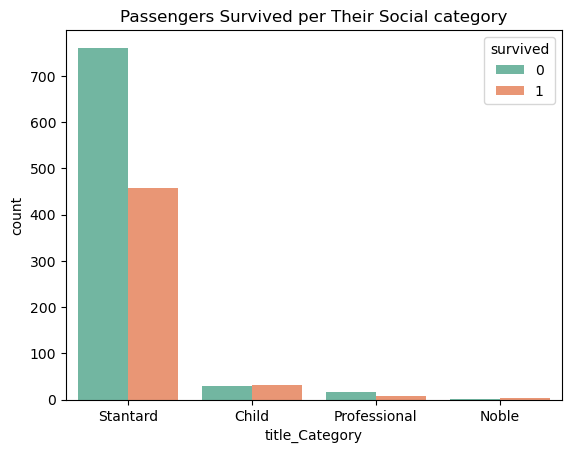

In [107]:
sns.countplot(data =df, x = 'title_Category', hue = 'survived', palette = 'Set2')
plt.title('Passengers Survived per Their Social category')

In [108]:
survival_per_category = df.groupby(['title_Category','survived'])['survived'].count()
survival_per_category

title_Category  survived
Child           0            30
                1            31
Noble           0             2
                1             4
Professional    0            16
                1             7
Stantard        0           761
                1           458
Name: survived, dtype: int64

Number of Survival per Category is visualized & calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Survival Breakdown by Category & Sex</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    Total survivor counts cross-tabulated by social category (<code>Pclass</code>) and gender (<code>Sex</code>) to evaluate combined demographic and socioeconomic survival rates.
  </p>
</div>

In [109]:
survival_per_category_and_sex = df.groupby(['title_Category','survived','sex'])['survived'].count()
survival_per_category_and_sex

title_Category  survived  sex   
Child           0         male       30
                1         male       31
Noble           0         male        2
                1         female      3
                          male        1
Professional    0         male       16
                1         female      1
                          male        6
Stantard        0         female    127
                          male      634
                1         female    335
                          male      123
Name: survived, dtype: int64

The Number of Survivors per Category and Sex is Calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #16a085; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #16a085; font-size: 13px;">📊 Family Status vs Survival Outcome </strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    passenger survival and mortality totals categorized by travel status (Alone vs. Traveling with Family) to measure the impact of companionship on survival rates.
  </p>
</div>

Text(0.5, 1.0, 'The Number of Alone passengers vs Number of Passengers who Survived or Died')

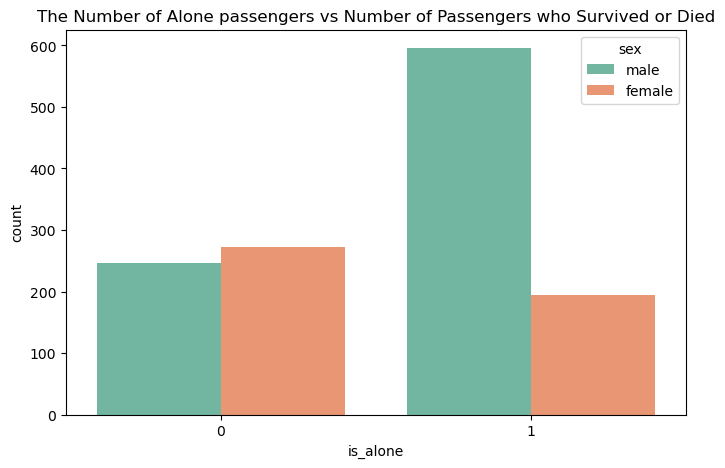

In [110]:
plt.figure(figsize=(8,5))
sns.countplot(data =df, x = 'is_alone', hue = 'sex', palette = 'Set2')
plt.title('The Number of Alone passengers vs Number of Passengers who Survived or Died')

In [111]:
is_alone_vs_survived = df.groupby(['is_alone','survived'])['survived'].count().reset_index(name='Total')


In [112]:
is_alone_vs_survived 

,is_alone,survived,Total
0,0,0,258
1,0,1,261
2,1,0,551
3,1,1,239


The Number of Alone Passengers who survived vs Number of Family Passengers who Survived is visualized & calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #8e44ad; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #8e44ad; font-size: 13px;">📊 Surviving Passengers: Alone vs. Family by Sex</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    The number of survivors who traveled alone compared to those with family, broken down by gender (<code>Sex</code>) to evaluate intersectional support dynamics during the disaster.
  </p>
</div>

In [113]:
is_alone_vs_survivedvssex = df.groupby(['is_alone','survived','sex'])['survived'].count().reset_index(name='Total')

In [114]:
is_alone_vs_survivedvssex

,is_alone,survived,sex,Total
0,0,0,female,75
1,0,0,male,183
2,0,1,female,197
3,0,1,male,64
4,1,0,female,52
5,1,0,male,499
6,1,1,female,142
7,1,1,male,97


The Number of Alone Passengers who survived vs Number of Family Passengers who Survived per Sex is calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Survival Breakdown by Family Type </strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    Passenger survival and mortality totals categorized by family size type (e.g., Solo, Small Family, Large Family) to measure how household scale influenced survival.
  </p>
</div>

Text(0.5, 1.0, 'Survival per Family Type')

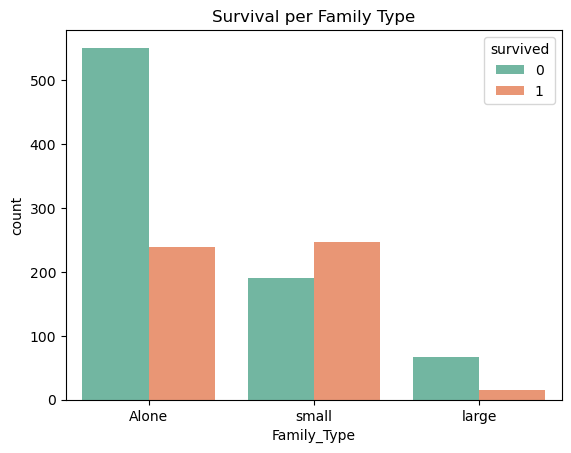

In [115]:
sns.countplot(data =df, x = 'Family_Type', hue = 'survived', palette = 'Set2')
plt.title('Survival per Family Type')

In [116]:
survived_per_family_type = df.groupby(['Family_Type','survived'])['survived'].count()
survived_per_family_type

Family_Type  survived
Alone        0           551
             1           239
large        0            67
             1            15
small        0           191
             1           246
Name: survived, dtype: int64

The Number of passengers who survived per Family_Type is visualized & calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #16a085; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #16a085; font-size: 13px;">📊 Survival Breakdown by Family Type & Sex</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    Total survivor counts cross-tabulated by family configuration type (Solo, Small Family, Large Family) and gender (<code>Sex</code>) to evaluate intersectional household survival dynamics.
  </p>
</div>

In [117]:
survived_per_family_type_sex = df.groupby(['Family_Type','survived','sex'])['survived'].count()
survived_per_family_type_sex

Family_Type  survived  sex   
Alone        0         female     52
                       male      499
             1         female    142
                       male       97
large        0         female     29
                       male       38
             1         female     12
                       male        3
small        0         female     46
                       male      145
             1         female    185
                       male       61
Name: survived, dtype: int64

The Number of passengers who survived per Family_Type and sex is calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #7f8c8d; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #7f8c8d; font-size: 13px;">📊 Survival Breakdown by Body Recovery Record</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    Passenger outcomes against body recovery records (<code>Body</code> column) to cross-reference post-mortem recovery data with survival status.
  </p>
</div>

Text(0.5, 1.0, 'Survival per Body Recovered')

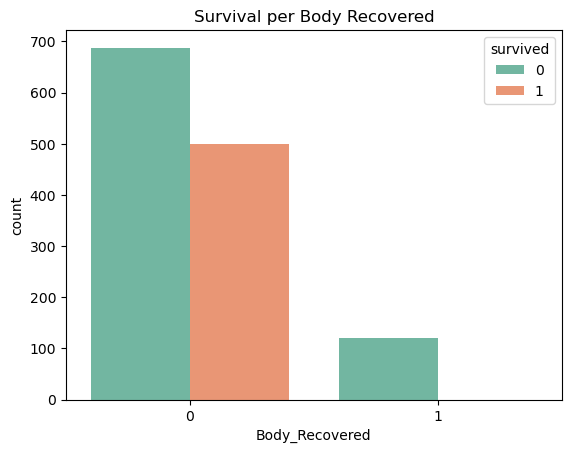

In [118]:
sns.countplot(data = df, x ='Body_Recovered' ,hue ='survived',palette =('Set2') )
plt.title('Survival per Body Recovered')

In [119]:
survived_body = df.groupby(['Body_Recovered','survived'])['survived'].count().reset_index(name = 'count')

In [120]:
survived_body

,Body_Recovered,survived,count
0,0,0,688
1,0,1,500
2,1,0,121


The Number of passengers who died and survived per Body Recovered is visualized & calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #d35400; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #d35400; font-size: 13px;">📊 Survival & Mortality Distribution by Embarkation Port</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    Passenger survival and mortality totals across different embarkation ports (<code>Embarked</code>) to analyze how boarding location influenced survival outcomes.
  </p>
</div>

Text(0.5, 1.0, 'The Number of passengers survived and Died Per Embarked Location')

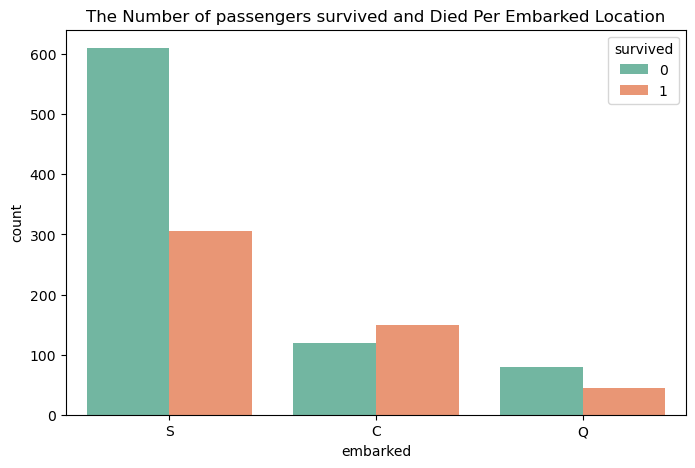

In [121]:
plt.figure(figsize=(8,5))
sns.countplot(data = df, x = 'embarked',hue = 'survived',palette = 'Set2')
plt.title('The Number of passengers survived and Died Per Embarked Location')

In [122]:
survived_per_embarked_location = df.groupby(['embarked','survived'])['survived'].count().reset_index(name = 'count')
survived_per_embarked_location

,embarked,survived,count
0,C,0,120
1,C,1,150
2,Q,0,79
3,Q,1,44
4,S,0,610
5,S,1,306


Survival and deaths per Embarked Location is Visualized calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Survival Rate by Embarkation Port & Sex</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    The percentage survival rates cross-tabulated by gender (<code>Sex</code>) and embarkation port (<code>Embarked</code>) to analyze intersectional survival probabilities.
  </p>
</div>

Text(0.5, 1.0, 'The Survival Rate of Male& Female Passengers per Embarked Location')

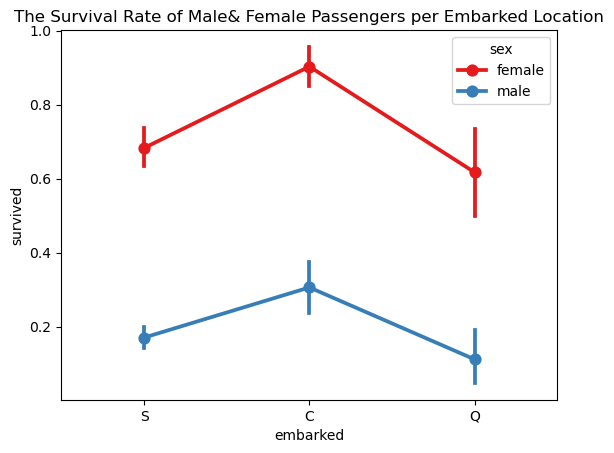

In [123]:
sns.pointplot(data = df, x ='embarked', y= 'survived', hue = 'sex', palette = 'Set1')
plt.title('The Survival Rate of Male& Female Passengers per Embarked Location')

In [124]:
survival_sex_embarked = df.groupby(['embarked','sex'])['survived'].mean().reset_index(name ='Average')
survival_sex_embarked

,embarked,sex,Average
0,C,female,0.902655
1,C,male,0.305732
2,Q,female,0.616667
3,Q,male,0.111111
4,S,female,0.682594
5,S,male,0.170144


The Survival Rate of Passengers per Embarked Location is visualized & Calculated

<div style="background-color: #f8f9fa; border-left: 4px solid #8e44ad; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #8e44ad; font-size: 13px;">📊 Age Distribution by Ship Deck</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    Extracted deck identifiers from cabin numbers (<code>Cabin</code>) and analyzed the age statistics (mean, median, and range) of passengers residing on each deck.
  </p>
</div>

Text(0.5, 1.0, 'Age of Passengers per deck')

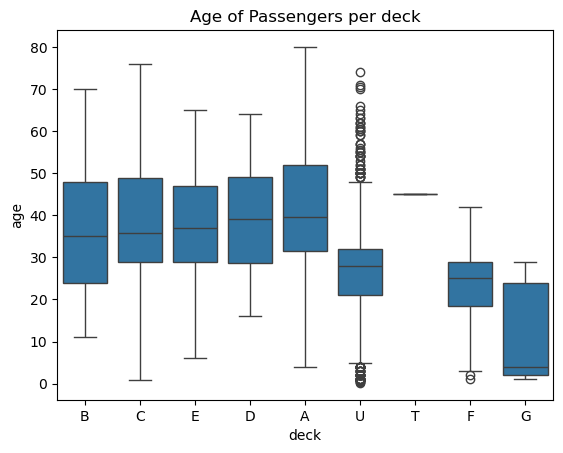

In [125]:
sns.boxplot(x='deck',y='age',data = df)
plt.title('Age of Passengers per deck')

<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Mean Age Per Deck</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    
  </p>
</div>

In [126]:
age_per_deck=df.groupby('deck')['age'].mean().reset_index(name='Average').round(3)
age_per_deck

,deck,Average
0,A,42.091
1,B,36.346
2,C,37.723
3,D,38.913
4,E,37.439
5,F,22.095
6,G,12.000
7,T,45.000
8,U,27.415


<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Max Age Per Deck</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    
  </p>
</div>

In [127]:
max_age_per_deck=df.groupby('deck')['age'].max().reset_index(name='Max_Age').round(3)
max_age_per_deck

,deck,Max_Age
0,A,80.0
1,B,70.0
2,C,76.0
3,D,64.0
4,E,65.0
5,F,42.0
6,G,29.0
7,T,45.0
8,U,74.0


<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Min Age Per Deck</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    
  </p>
</div>

In [128]:
min_age_per_deck=df.groupby('deck')['age'].min().reset_index(name='Min_Age').round(3)
min_age_per_deck

,deck,Min_Age
0,A,4.00
1,B,11.00
2,C,0.92
3,D,16.00
4,E,6.00
5,F,1.00
6,G,1.00
7,T,45.00
8,U,0.17


<div style="background-color: #f8f9fa; border-left: 4px solid #2980b9; padding: 10px 14px; border-radius: 4px; margin: 12px 0;">
  <strong style="color: #2980b9; font-size: 13px;">📊 Median Age Per Deck</strong>
  <p style="margin: 4px 0 0 0; color: #555555; font-size: 13px;">
    
  </p>
</div>

In [129]:
median_age_per_deck=df.groupby('deck')['age'].median().reset_index(name='Median_Age').round(3)
median_age_per_deck

,deck,Median_Age
0,A,39.50
1,B,35.00
2,C,35.75
3,D,39.00
4,E,37.00
5,F,25.00
6,G,4.00
7,T,45.00
8,U,28.00


Mean,Median,Max,Min Age of Passengers per Deck is visualized and Calculated